# 02 - Analyse Exploratoire des Données (EDA)

---
## Objectif de l'étape

L'analyse exploratoire (EDA) est une étape essentielle qui permet :
- de comprendre la structure générale du dataset
- d'identifier les tendances principales (produits, clients, pays)
- de détecter des anomalies ou comportements atypiques
- de préparer les futures étapes (segmentation, modélisation, dashboard)

---

## Méthodologie


Chaque graphique ou statistique est choisi pour répondre à une question précise :
- **Statistiques descriptives** : donner une vue d’ensemble (transactions, clients, produits, pays, valeur totale).
- **Distribution des variables** : comprendre la répartition des quantités et des prix unitaires.
- **Produits phares et pays principaux** : identifier les éléments qui génèrent le plus de volume.
- **Analyse temporelle** : observer les ventes par mois, jour de la semaine et heure pour détecter des tendances saisonnières ou des pics d’activité.

---

## Structure du notebook
1. Statistiques descriptives
2. Distribution des quantités
3. Distribution des prix unitaires
4. Produits les plus vendus
5. Pays principaux
6. Analyse temporelle

---
   

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# charger le dataset nettoyé
df = pd.read_csv('../data/processed/OnlineRetail_clean.csv')
# ajout de la colonne TotalPrice pour l'EDA
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']
print('Dataset chargé :', df.shape)

Dataset chargé : (392692, 9)


In [4]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


In [5]:
df.tail()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
392687,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680,France,10.20
392688,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680,France,12.60
392689,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680,France,16.60
392690,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680,France,16.60
392691,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680,France,14.85


In [6]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'TotalPrice'],
      dtype='object')

---
# 1. Statistiques descriptives

## Pourquoi ?

Les statistiques descriptives donnent une vue d'ensemble du dataset : nombre de transactions, clients, produits, pays et valeur total des ventes. 

Cela permet de situer l'échelle de l'activité

---

In [7]:
print('Nombre de transactions :', df['InvoiceNo'].nunique())
print('Nombre de clients :', df['CustomerID'].nunique())
print('Nombre de produits :', df['StockCode'].nunique())
print('Nombre de pays :', df['Country'].nunique())
print('Valeur totale des ventes :', round(df['TotalPrice'].sum(), 2))

Nombre de transactions : 18532
Nombre de clients : 4338
Nombre de produits : 3665
Nombre de pays : 37
Valeur totale des ventes : 8887208.89


In [8]:
type(df['TotalPrice'])

pandas.core.series.Series

In [9]:
df.dtypes

InvoiceNo        int64
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID       int64
Country         object
TotalPrice     float64
dtype: object

In [10]:
df[['Quantity','UnitPrice','TotalPrice']].describe()

,Quantity,UnitPrice,TotalPrice
count,392692.000000,392692.000000,392692.000000
mean,13.119702,3.125914,22.631500
std,180.492832,22.241836,311.099224
min,1.000000,0.001000,0.001000
25%,2.000000,1.250000,4.950000
50%,6.000000,1.950000,12.450000
75%,12.000000,3.750000,19.800000
max,80995.000000,8142.750000,168469.600000


---
# 2. Distribution des quantités

## Pourquoi ?

Un histogramme des quantités montre si les commandes sont généralement petites ou s'il existe des achats massifs. Cela aide à détecter des comportements atypiques.

---

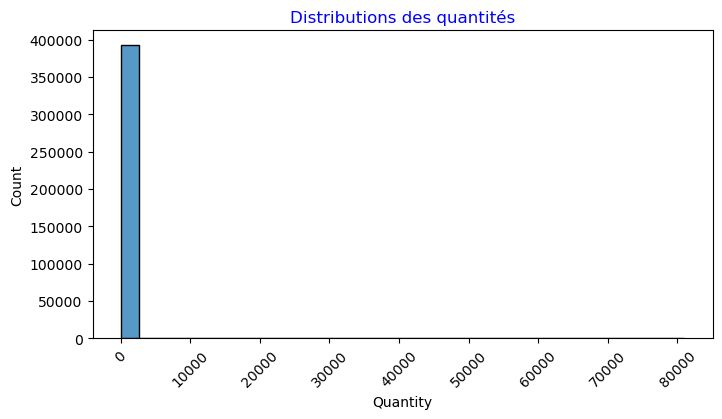

In [11]:
# histogramme
plt.figure(figsize=(8, 4))
sns.histplot(df['Quantity'], bins=30)
plt.title('Distributions des quantités', color='Blue')
plt.xticks(rotation=45)
plt.show()

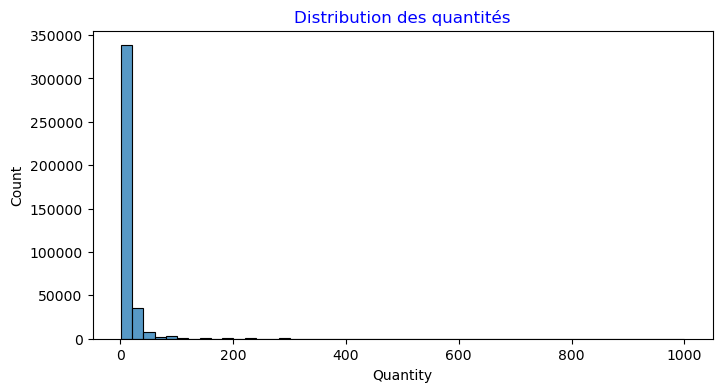

In [80]:
# définition des bornes pour filtrer les outliers
# ici on garde uniquement les quantités entre -1000 et 1000
df_filtered = df[(df['Quantity'] >=- 1000) & (df['Quantity'] <= 1000)]

# histogramme
plt.figure(figsize=(8, 4))
sns.histplot(df_filtered['Quantity'], bins=50, kde=False)
plt.title('Distribution des quantités', color='Blue')
plt.savefig("../outputs/figures/01_distribution_quantites.png", dpi=150, bbox_inches="tight")
plt.show()

In [13]:
sales = df[df['Quantity'] > 0]
returns = df[df['Quantity'] < 0]
print('Nombre de ventes :', len(sales))
print('Nombre de retours :', len(returns))

Nombre de ventes : 392692
Nombre de retours : 0


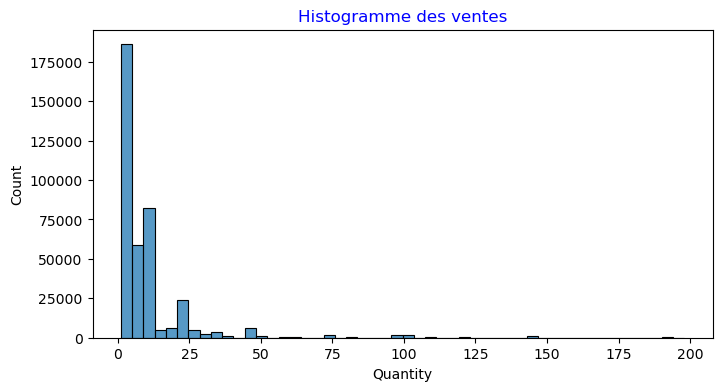

In [14]:
# histogramme
plt.figure(figsize=(8, 4))
sns.histplot(df.loc[(df['Quantity'] > 0) & (df['Quantity'] < 200), 'Quantity'], bins=50, kde=False)
plt.title('Histogramme des ventes', color='Blue')
plt.show()

In [15]:
# médiane, quartiles, outliers
moyenne = df['Quantity'].mean()
mediane = df['Quantity'].median()
quan_max = df['Quantity'].max()
quan_min = df['Quantity'].min()
Q1 = df['Quantity'].quantile(0.25)
Q2 = df['Quantity'].quantile(0.5)
Q3 = df['Quantity'].quantile(0.75)

print(f"La moyenne est :{moyenne:.2f}")
print(f"La médiane est :{mediane:.2f}")
print(f"La quantité maximale est: {quan_max:.2f}")
print(f"La quantité minimale est :{quan_min:.2f}")
print(f"Le premier quartile est :{Q1:.2f}")
print(f"Le deuxième quartile (médiane) est :{Q2:.2f}")
print(f"Le troisième quartile est :{Q3:.2f}")

La moyenne est :13.12
La médiane est :6.00
La quantité maximale est: 80995.00
La quantité minimale est :1.00
Le premier quartile est :2.00
Le deuxième quartile (médiane) est :6.00
Le troisième quartile est :12.00


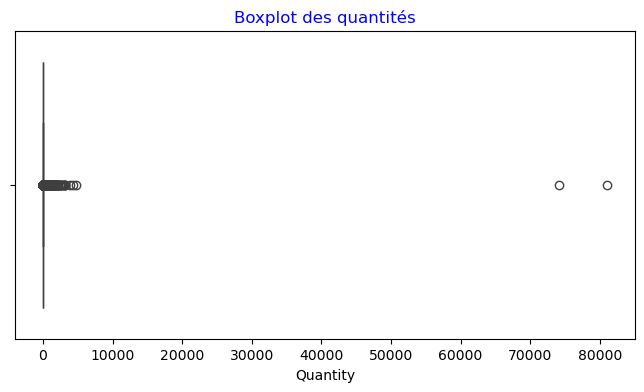

In [16]:
# boxplot
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['Quantity'])
plt.title('Boxplot des quantités', color='Blue')
plt.show()

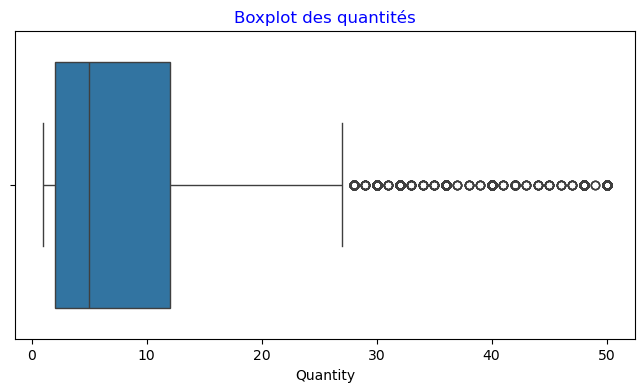

In [17]:
# boxplot filtré
plt.figure(figsize=(8,4))
sns.boxplot(x=df[df['Quantity'] <= 50]['Quantity'])
plt.title('Boxplot des quantités', color='Blue')
plt.show()

---
# 3. Distribution des prix unitaires

## Pourquoi ?

Analyser les prix unitaires permet de comprendre la game de produits: bon marché ou premium. Cela aide à positionner l'entreprise

---

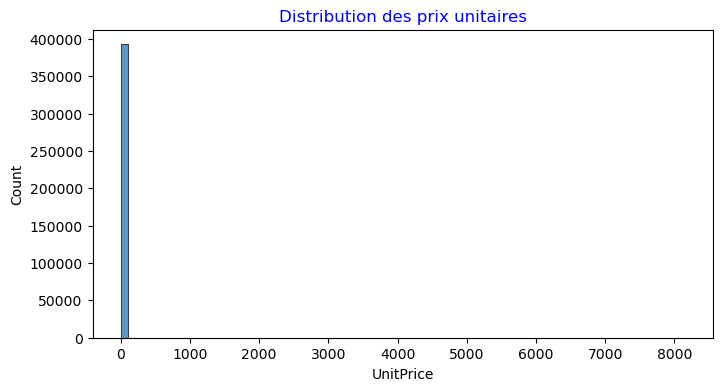

In [18]:
# histogramme
plt.figure(figsize=(8,4))
sns.histplot(df['UnitPrice'], bins=80, kde=False)
plt.title('Distribution des prix unitaires', color='Blue')
plt.show()

In [19]:
prix_positifs = df[df['UnitPrice'] > 0]
prix_negatifs = df[df['UnitPrice'] < 0]
print('prix positifs :', len(prix_positifs))
print('prix négatifs :', len(prix_negatifs))

prix positifs : 392692
prix négatifs : 0


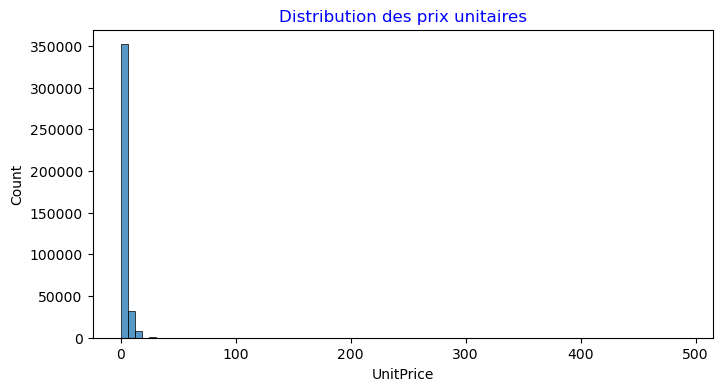

In [81]:
df_filtered = df.loc[(df['UnitPrice']>0) & (df['UnitPrice']<500), 'UnitPrice']
plt.figure(figsize=(8,4))
sns.histplot(df_filtered, bins=80)
plt.title('Distribution des prix unitaires', color='Blue')
plt.savefig("../outputs/figures/02_distribution_prix.png", dpi=150, bbox_inches="tight")
plt.show()

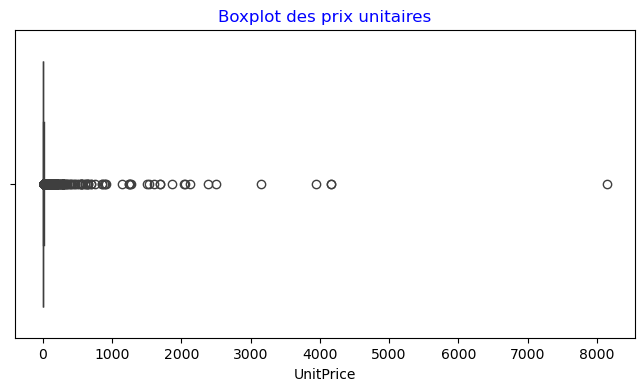

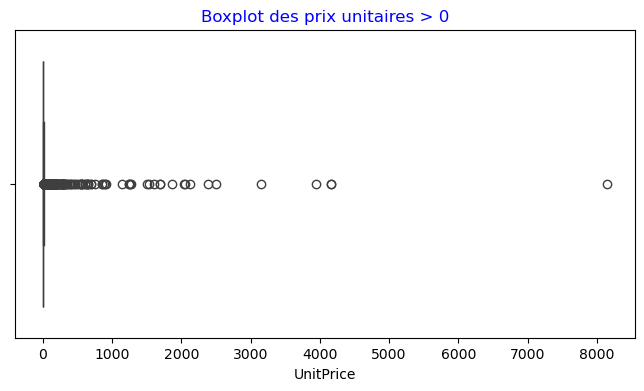

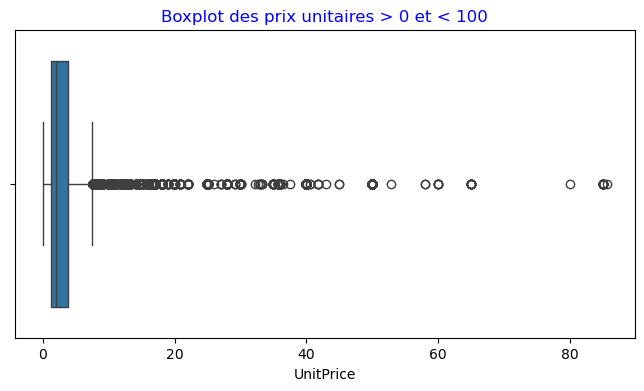

In [82]:
# boxplot
plt.figure(figsize=(8,4))
sns.boxplot(x=df['UnitPrice'])
plt.title('Boxplot des prix unitaires',color='Blue')
plt.show()

plt.figure(figsize=(8,4))
sns.boxplot(x= df[(df['UnitPrice'] > 0)]['UnitPrice'])
plt.title('Boxplot des prix unitaires > 0', color='Blue')
plt.show()

plt.figure(figsize=(8,4))
sns.boxplot(x= df[(df['UnitPrice'] > 0) & (df['UnitPrice'] < 100)]['UnitPrice'])
plt.title('Boxplot des prix unitaires > 0 et < 100', color='Blue')
plt.show()

---
# 4. Produits les plus vendus

## Pourquoi ?

Identifier les produits phares permet de savoir quels articles génèrent le plus de volume de ventes.  
C’est une information stratégique pour :
- Orienter les décisions marketing (promotions, campagnes ciblées).
- Optimiser la gestion des stocks.
- Comprendre la concentration du chiffre d’affaires sur quelques références.
  
---
## Observation attendue
On s’attend à voir une forte concentration des ventes sur un petit nombre de produits.  
Cela signifie que l’activité repose sur des articles clés, tandis que la majorité des autres produits ont un volume plus faible.

---

In [22]:
# produits par quantité vendue top 10
top_products1 = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)
top_products1

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54319
JUMBO BAG RED RETROSPOT               46078
WHITE HANGING HEART T-LIGHT HOLDER    36706
ASSORTED COLOUR BIRD ORNAMENT         35263
PACK OF 72 RETROSPOT CAKE CASES       33670
POPCORN HOLDER                        30919
RABBIT NIGHT LIGHT                    27153
MINI PAINT SET VINTAGE                26076
Name: Quantity, dtype: int64

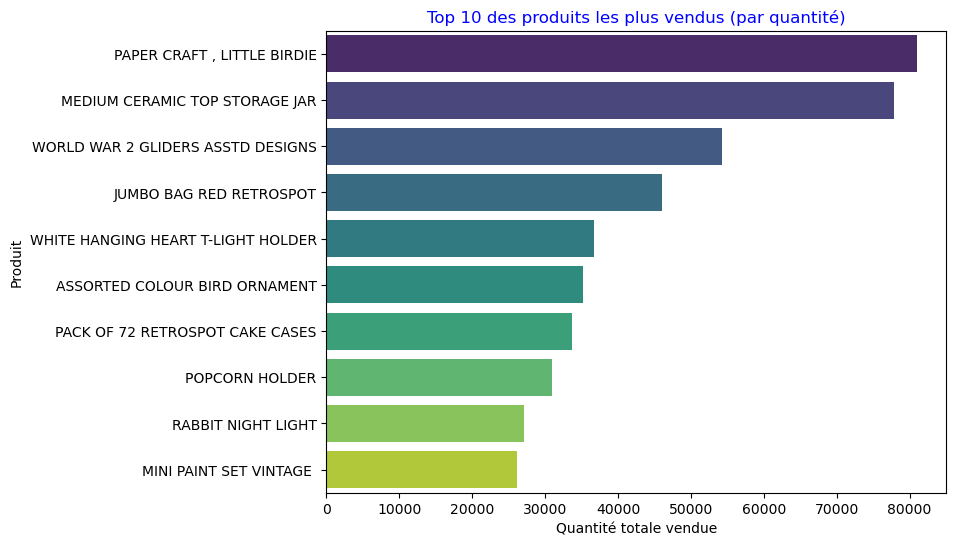

In [83]:
# barplot des produits par quantité
plt.figure(figsize=(8,6))
sns.barplot(x=top_products1.values, y=top_products1.index, palette='viridis', hue=top_products1.index)
plt.title('Top 10 des produits les plus vendus (par quantité)', color='Blue')
plt.xlabel('Quantité totale vendue')
plt.ylabel('Produit')
plt.savefig("../outputs/figures/03_top_produits_quantite.png", dpi=150, bbox_inches="tight")
plt.show()

In [24]:
# produits par chiffre d'affaires Top 10
top_products2 = df.groupby('Description')['TotalPrice'].sum().sort_values(ascending=False).head(10)
top_products2

Description
PAPER CRAFT , LITTLE BIRDIE           168469.60
REGENCY CAKESTAND 3 TIER              142264.75
WHITE HANGING HEART T-LIGHT HOLDER    100392.10
JUMBO BAG RED RETROSPOT                85040.54
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
POSTAGE                                77803.96
PARTY BUNTING                          68785.23
ASSORTED COLOUR BIRD ORNAMENT          56413.03
Manual                                 53419.93
RABBIT NIGHT LIGHT                     51251.24
Name: TotalPrice, dtype: float64

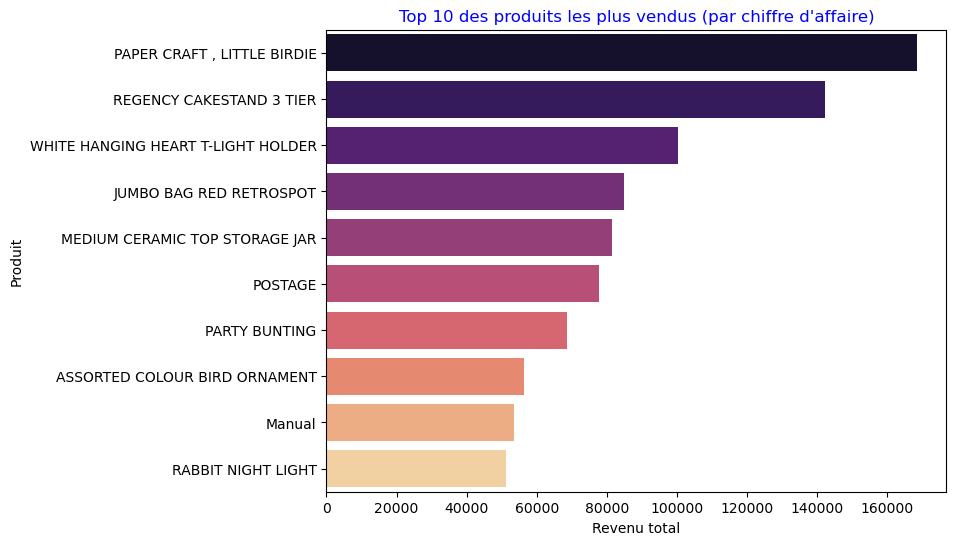

In [25]:
# barplot Top 10 des produits
plt.figure(figsize=(8,6))
sns.barplot(x=top_products2.values, y=top_products2.index, palette='magma', hue=top_products2.index)
plt.title('Top 10 des produits les plus vendus (par chiffre d\'affaire)', color='Blue')
plt.xlabel('Revenu total')
plt.ylabel('Produit')
plt.show()

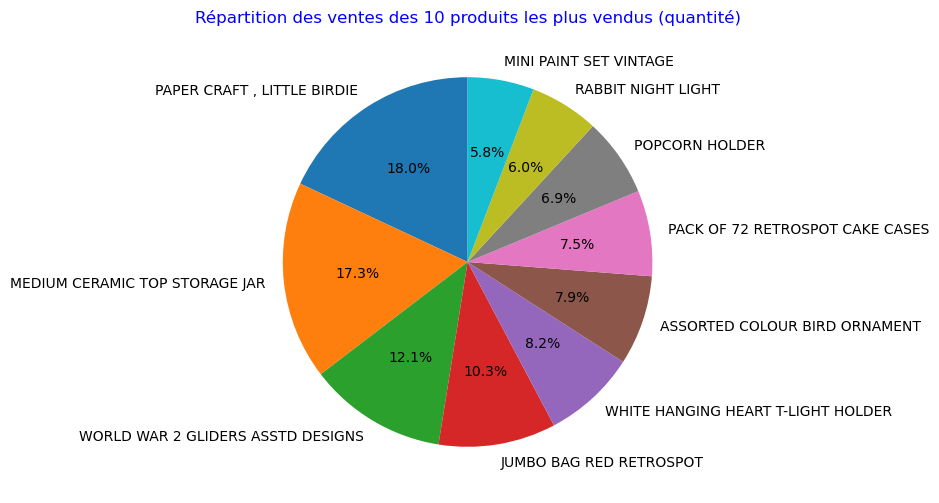

In [84]:
# camembert (pie chart) par quantité
plt.figure(figsize=(8,6))
plt.pie(top_products1, labels=top_products1.index, autopct='%1.1f%%', startangle=90)
plt.title('Répartition des ventes des 10 produits les plus vendus (quantité)', color='Blue')
plt.savefig("../outputs/figures/03_top_produits_quantite.png", dpi=150, bbox_inches="tight")
plt.show()

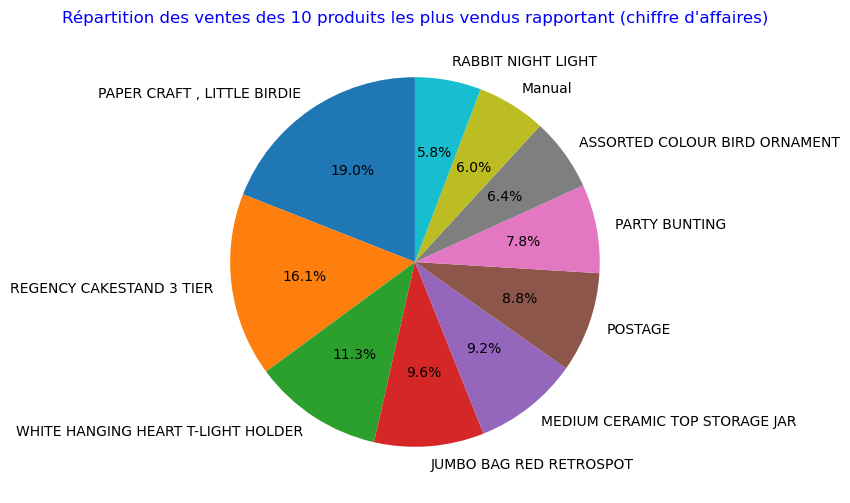

In [27]:
plt.figure(figsize=(8,6))
plt.pie(top_products2, labels=top_products2.index, autopct='%1.1f%%', startangle=90)
plt.title('Répartition des ventes des 10 produits les plus vendus rapportant (chiffre d\'affaires)', color='Blue')
plt.show()

---
# 5. Pays principaux

## Pourquoi ?

Identifier les principaux marchés permet de comprendre où se concentre le chiffre d'affaires.
Cela aide à orienter les décisions stratégiques et commerciales.

C'est une information clé pour :
- Adapter les stratégies marketing selon les zones géographiques
- Identifier les marchés à fort potentiel
- Réduire la dépendance à un nombre limité de pays

---
## Observation attendue

On s’attend à observer une concentration du chiffre d’affaires sur quelques pays principaux.

Cela signifie que l’activité commerciale est dominée par certains marchés clés, tandis que les autres pays contribuent de manière plus marginale.

Cette répartition met en évidence :
- les zones de forte performance
- les opportunités d’expansion sur des marchés moins exploités

---

In [28]:
# liste des pays
liste_pays = df['Country'].unique()
print('Liste de tous les pays: \n', liste_pays)
nb = df['Country'].nunique()
print('\nNbre total de pays: ', nb)

Liste de tous les pays: 
 ['United Kingdom' 'France' 'Australia' 'Netherlands' 'Germany' 'Norway'
 'EIRE' 'Switzerland' 'Spain' 'Poland' 'Portugal' 'Italy' 'Belgium'
 'Lithuania' 'Japan' 'Iceland' 'Channel Islands' 'Denmark' 'Cyprus'
 'Sweden' 'Finland' 'Austria' 'Greece' 'Singapore' 'Lebanon'
 'United Arab Emirates' 'Israel' 'Saudi Arabia' 'Czech Republic' 'Canada'
 'Unspecified' 'Brazil' 'USA' 'European Community' 'Bahrain' 'Malta' 'RSA']

Nbre total de pays:  37


In [29]:
# top 10 des pays les plus rapportant
revenu_by_country = df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10)
revenu_by_country

Country
United Kingdom    7285024.644
Netherlands        285446.340
EIRE               265262.460
Germany            228678.400
France             208934.310
Australia          138453.810
Spain               61558.560
Switzerland         56443.950
Belgium             41196.340
Sweden              38367.830
Name: TotalPrice, dtype: float64

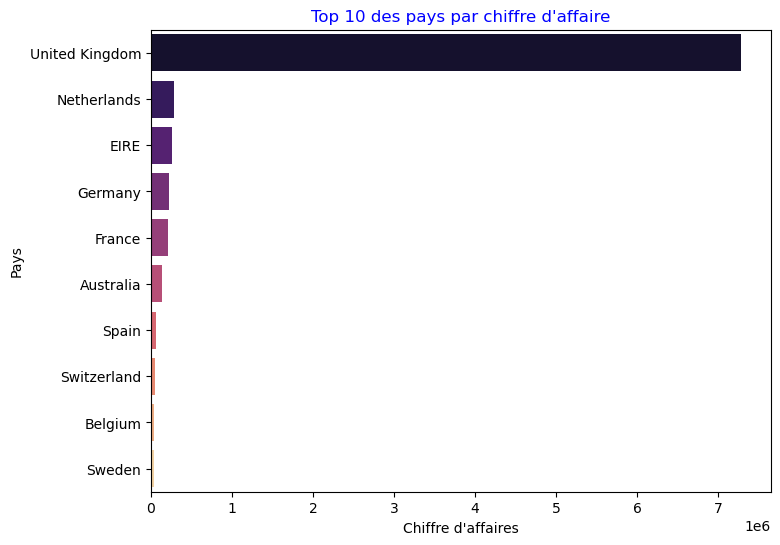

In [85]:
# barplot
plt.figure(figsize=(8,6))
sns.barplot(x=revenu_by_country.values, y=revenu_by_country.index, palette='magma', hue=revenu_by_country.index)
plt.title('Top 10 des pays par chiffre d\'affaire', color='Blue')
plt.xlabel('Chiffre d\'affaires')
plt.ylabel('Pays')
plt.savefig("../outputs/figures/04_top_pays.png", dpi=150, bbox_inches="tight")
plt.show()

In [31]:
cumultative = revenu_by_country.cumsum() / revenu_by_country.sum()
cumultative.head(10)

Country
United Kingdom    0.846174
Netherlands       0.879330
EIRE              0.910141
Germany           0.936702
France            0.960970
Australia         0.977052
Spain             0.984202
Switzerland       0.990758
Belgium           0.995543
Sweden            1.000000
Name: TotalPrice, dtype: float64

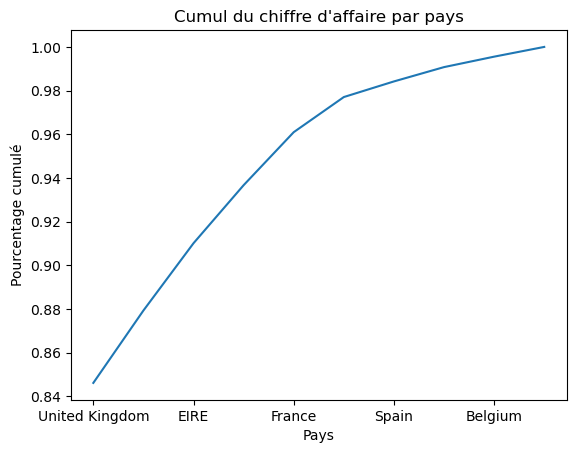

In [32]:
cumultative.head(10).plot()
plt.title("Cumul du chiffre d'affaire par pays")
plt.xlabel("Pays")
plt.ylabel("Pourcentage cumulé")
plt.show()

---
### Analyse de la concentration géographique

Le Royaume-Uni représente à lui seul environ 85 % du chiffre d’affaires total, ce qui indique une très forte concentration des ventes sur ce marché.

Les autres pays contribuent de manière progressive mais nettement plus faible, comme le montre l’augmentation graduelle du pourcentage cumulatif.

Cette distribution met en évidence une dépendance importante à un seul marché, tandis que les autres zones géographiques restent sous-exploitées.

---
### Implications

* Le Royaume-Uni constitue le marché principal et un levier stratégique majeur
* La forte dépendance à ce marché peut représenter un risque
* Les autres pays offrent un potentiel de diversification et de croissance
---

# 6. Analyse temporelle des ventes

L’analyse temporelle constitue la dernière étape de notre EDA. Elle vise à comprendre comment les ventes évoluent dans le temps, à identifier les tendances et les comportements saisonniers, ainsi qu’à repérer les anomalies. Cette étape est particulièrement importante en e-commerce, où la demande varie selon les périodes, les jours et même les heures.

---

## Objectifs
- Étudier l’évolution des transactions et du chiffre d’affaires dans le temps.
- Identifier les périodes de forte et faible activité.
- Mettre en évidence la saisonnalité et les tendances.
- Comparer les comportements selon les pays et les heures de la journée.
- Détecter les anomalies ou événements exceptionnels.

---

## Analyses réalisées
- **Transactions quotidiennes et mensuelles** : évolution du volume des ventes.
- **Chiffre d’affaires dans le temps** : suivi des revenus par jour et par mois.
- **Heatmap jour/heure** : activité moyenne selon le jour de la semaine et l’heure.
- **Analyse saisonnière** : décomposition en tendance, saisonnalité et résidu.
- **Comparaison par pays** : évolution des ventes dans les principaux marchés.
- **Analyse par heure** : distribution des ventes au cours de la journée.
- **Détection d’anomalies** : identification des jours atypiques.

---

## Visualisations prévues
- Courbes de séries temporelles (transactions et revenus).
- Histogrammes mensuels.
- Heatmap jour/heure.
- Boxplots par mois.
- Graphiques de décomposition (tendance/saisonnalité).
- Comparaisons multi-pays.

---

## Conclusion
Cette analyse temporelle complète l’exploration des données. Elle servira de base à la création d’une application interactive avec **Streamlit**, permettant :
- La sélection dynamique de périodes, pays et produits.
- L’affichage de graphes interactifs (Plotly).
- La mise en place d’un dashboard décisionnel pour l’e-commerce.

In [33]:
# transactions quotidiennes: nbre de factures par jour
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
daily_transaction = df.groupby(df['InvoiceDate'].dt.date)['InvoiceNo'].nunique()
daily_transaction

InvoiceDate
2010-12-01    121
2010-12-02    137
2010-12-03     57
2010-12-05     87
2010-12-06     94
             ... 
2011-12-05    116
2011-12-06    110
2011-12-07    104
2011-12-08    113
2011-12-09     41
Name: InvoiceNo, Length: 305, dtype: int64

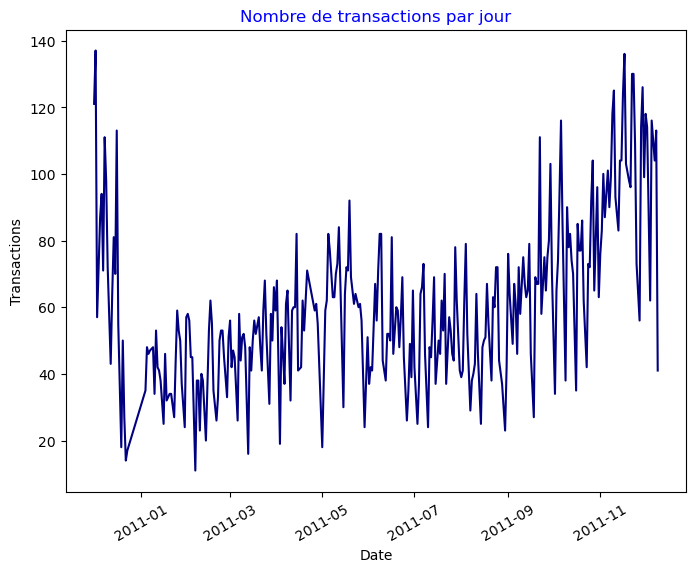

In [34]:
plt.figure(figsize=(8, 6))
sns.lineplot(x=daily_transaction.index, y=daily_transaction.values, color='navy')
plt.title('Nombre de transactions par jour', color='Blue')
plt.xlabel('Date')
plt.ylabel('Transactions')
plt.xticks(rotation=30)
plt.show()

In [35]:
# transactions par mois
monthly_transaction = df.groupby(df['InvoiceDate'].dt.to_period('M'))['InvoiceNo'].nunique()
monthly_transaction

InvoiceDate
2010-12    1400
2011-01     987
2011-02     997
2011-03    1321
2011-04    1149
2011-05    1555
2011-06    1393
2011-07    1331
2011-08    1280
2011-09    1755
2011-10    1929
2011-11    2657
2011-12     778
Freq: M, Name: InvoiceNo, dtype: int64

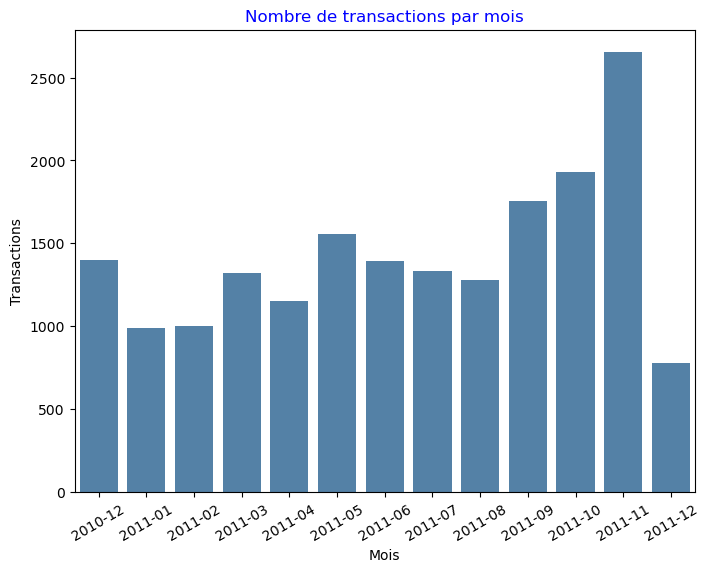

In [36]:
# barplot
plt.figure(figsize=(8, 6))
sns.barplot(monthly_transaction, color='steelblue')
plt.title('Nombre de transactions par mois', color='Blue')
plt.xlabel('Mois')
plt.ylabel('Transactions')
plt.xticks(rotation=30)
plt.show()

In [37]:
# revenu quotidien: somme du CA par jour
daily_revenu = df.groupby(df['InvoiceDate'].dt.date)['TotalPrice'].sum()
daily_revenu

InvoiceDate
2010-12-01     46192.49
2010-12-02     47197.57
2010-12-03     23876.63
2010-12-05     31361.28
2010-12-06     31009.33
                ...    
2011-12-05     58081.09
2011-12-06     45989.66
2011-12-07     69230.60
2011-12-08     50395.96
2011-12-09    184329.66
Name: TotalPrice, Length: 305, dtype: float64

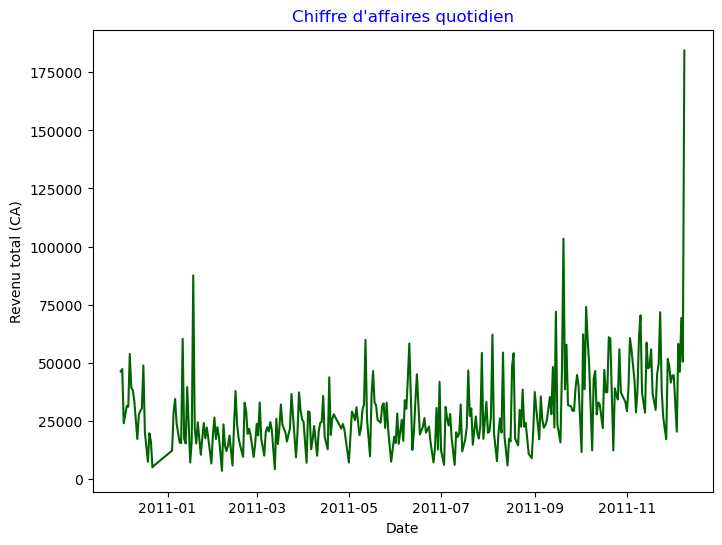

In [86]:
plt.figure(figsize=(8, 6))
sns.lineplot(x=daily_revenu.index, y=daily_revenu.values,color='darkgreen')
plt.title('Chiffre d\'affaires quotidien', color='Blue')
plt.xlabel('Date')
plt.ylabel('Revenu total (CA)')
plt.savefig("../outputs/figures/05_evolution_temporelle.png", dpi=150, bbox_inches="tight")
plt.show()

In [39]:
# revenu mensuel
monthly_revenu = df.groupby(df['InvoiceDate'].dt.to_period('M'))['TotalPrice'].sum()
monthly_revenu

InvoiceDate
2010-12     570422.730
2011-01     568101.310
2011-02     446084.920
2011-03     594081.760
2011-04     468374.331
2011-05     677355.150
2011-06     660046.050
2011-07     598962.901
2011-08     644051.040
2011-09     950690.202
2011-10    1035642.450
2011-11    1156205.610
2011-12     517190.440
Freq: M, Name: TotalPrice, dtype: float64

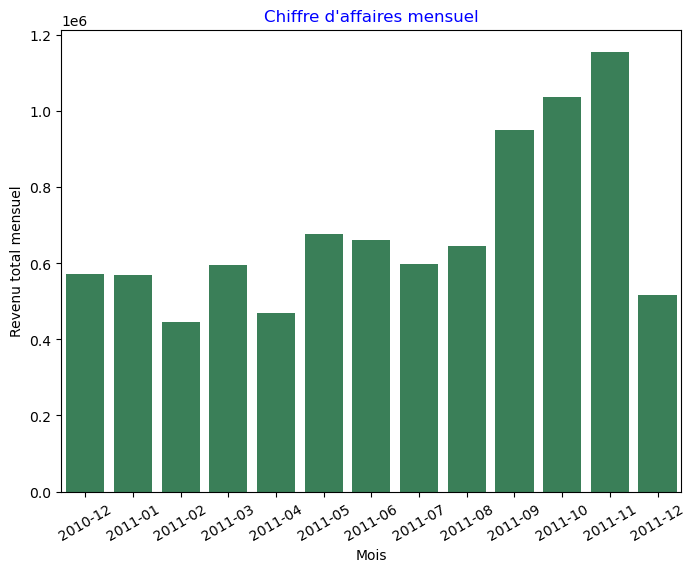

In [40]:
# barplot
plt.figure(figsize=(8,6))
sns.barplot(monthly_revenu, color='seagreen')
plt.title('Chiffre d\'affaires mensuel', color='Blue')
plt.xlabel('Mois')
plt.ylabel('Revenu total mensuel')
plt.xticks(rotation=30)
plt.show()

In [41]:
# heatmap jour/heure
    # extraire jour de la semaine et heure
df['weekday'] = df['InvoiceDate'].dt.day_name()
df['weekday']

0         Wednesday
1         Wednesday
2         Wednesday
3         Wednesday
4         Wednesday
            ...    
392687       Friday
392688       Friday
392689       Friday
392690       Friday
392691       Friday
Name: weekday, Length: 392692, dtype: object

In [42]:
df['hour'] = df['InvoiceDate'].dt.hour
df['hour']

0          8
1          8
2          8
3          8
4          8
          ..
392687    12
392688    12
392689    12
392690    12
392691    12
Name: hour, Length: 392692, dtype: int32

In [43]:
# moyenne du CA par jour et heure
heatmap_data = df.groupby(['weekday','hour'])['TotalPrice'].sum().unstack()
heatmap_data

hour,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20
weekday,,,,,,,,,,,,,,,
Friday,NaN,17284.88,52656.61,296376.831,182871.600,166546.63,229692.39,166967.81,159405.600,136863.93,43975.64,29971.160,75.50,373.04,19.19
Monday,NaN,1494.58,43343.39,123955.190,183627.120,160302.06,184573.40,225247.61,187624.200,140756.89,74536.32,38143.641,NaN,NaN,NaN
Sunday,NaN,NaN,NaN,778.800,80945.720,141532.10,152903.71,137280.88,104196.381,129053.66,38799.07,NaN,NaN,NaN,NaN
Thursday,4.25,6883.71,67844.25,134086.740,273576.910,170597.00,285465.97,196112.66,200940.160,229527.65,138245.01,114274.810,104372.86,45301.96,5781.79
Tuesday,NaN,2052.58,72383.27,164256.880,294899.041,260912.59,245024.38,211515.03,160735.040,167304.23,90360.21,27993.920,296.63,NaN,NaN
Wednesday,NaN,3343.46,45770.27,122937.900,243347.200,201287.22,276035.54,231600.21,179091.440,160053.32,81464.31,23428.060,NaN,2893.40,13031.50


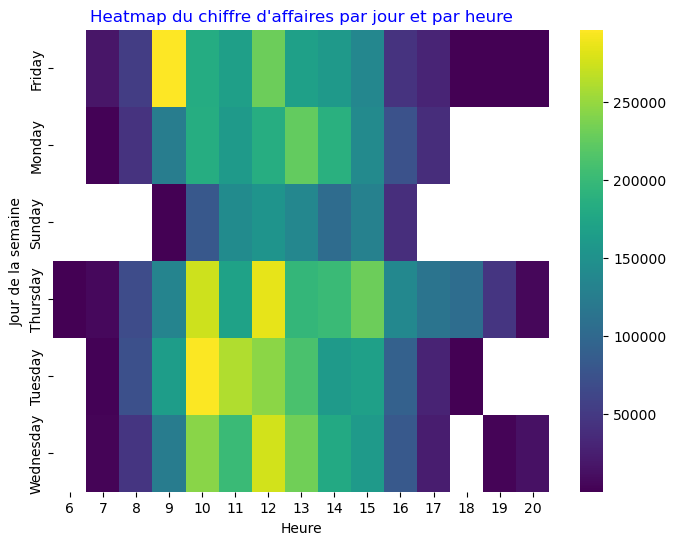

In [87]:
# heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(heatmap_data, cmap='viridis')
plt.title('Heatmap du chiffre d\'affaires par jour et par heure', color='Blue')
plt.xlabel('Heure')
plt.ylabel('Jour de la semaine')
plt.savefig("../outputs/figures/06_heatmap_jour_heure.png", dpi=150, bbox_inches="tight")
plt.show()

In [45]:
# boxplot par mois
df['month'] = df['InvoiceDate'].dt.month
df['month']

0         12
1         12
2         12
3         12
4         12
          ..
392687    12
392688    12
392689    12
392690    12
392691    12
Name: month, Length: 392692, dtype: int32

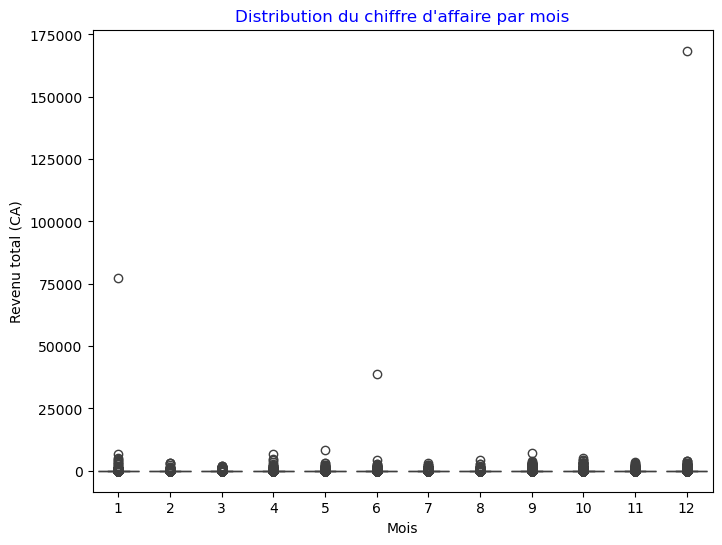

In [46]:
plt.figure(figsize=(8,6))
sns.boxplot(x='month', y='TotalPrice', data = df)
plt.title('Distribution du chiffre d\'affaire par mois', color='Blue')
plt.xlabel('Mois')
plt.ylabel('Revenu total (CA)')
plt.show()

In [47]:
from statsmodels.tsa.seasonal import STL
# serie journalière du CA
daily_revenu_serie = daily_revenu.asfreq('D').fillna(0)
daily_revenu_serie

InvoiceDate
2010-12-01     46192.49
2010-12-02     47197.57
2010-12-03     23876.63
2010-12-04         0.00
2010-12-05     31361.28
                ...    
2011-12-05     58081.09
2011-12-06     45989.66
2011-12-07     69230.60
2011-12-08     50395.96
2011-12-09    184329.66
Freq: D, Name: TotalPrice, Length: 374, dtype: float64

In [48]:
# décomposition STL
stl = STL(daily_revenu_serie, period=7) # saisonnalité hebdomadaire
result = stl.fit()
result

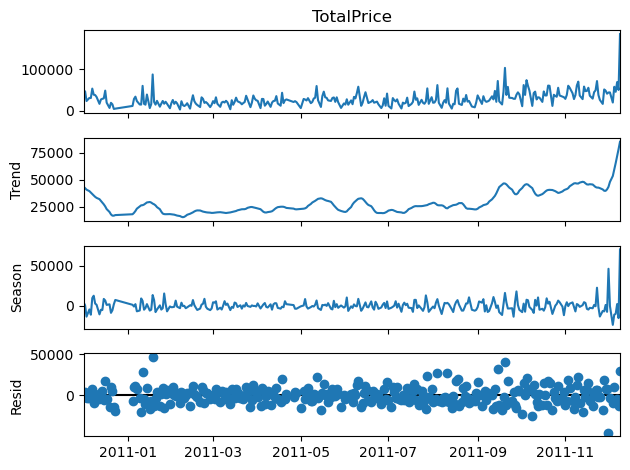

In [88]:
result.plot()
plt.savefig("../outputs/figures/07_decomposition_stl.png", dpi=150, bbox_inches="tight")
plt.show()

## Analyse saisonnière du chiffre d’affaires

La décomposition STL appliquée au chiffre d’affaires quotidien permet de séparer la série en trois composantes principales : **tendance**, **saisonnalité** et **résidu**. Cette approche est essentielle pour comprendre les mécanismes sous-jacents des ventes en e‑commerce.

  ### 1. Série originale (*TotalPrice*)
- Montre le chiffre d’affaires quotidien brut.
- Forte variabilité avec des pics marqués certains jours.
- Reflète la nature irrégulière des ventes en ligne, influencées par des événements ponctuels.

  ### 2. Tendance (*Trend*)
- Courbe lissée qui met en évidence l’évolution générale.
- On observe une baisse au milieu de l’année, suivie d’une remontée progressive vers la fin.
- Traduit un cycle annuel typique : creux au printemps/été, reprise à l’automne et pic en fin d’année (effet fêtes).

  ### 3. Saisonnalité (*Season*)
- Courbe oscillante qui se répète régulièrement.
- Met en évidence des patterns périodiques, probablement hebdomadaires.
- En e‑commerce, cela correspond souvent à des jours de forte activité (début de semaine, avant week‑end) et des jours plus calmes.

  ### 4. Résidu (*Resid*)
- Variations restantes après retrait de la tendance et de la saisonnalité.
- Représente le bruit ou les anomalies (jours exceptionnellement hauts ou bas).
- Utile pour détecter des événements inhabituels : promotions, commandes massives, erreurs de saisie.

  ### Conclusion
- L’activité suit une **tendance annuelle** : baisse au milieu de l’année, reprise en fin d’année.
- Une **saisonnalité régulière** est présente, probablement liée aux cycles hebdomadaires.
- Les **résidus** révèlent des anomalies qui méritent une analyse spécifique.

---
# Analyse par heure

## 1. Objectifs
- Étudier la distribution des ventes au cours de la journée.  
- Identifier les heures de forte activité (pics de commandes).  
- Vérifier si certains créneaux horaires sont systématiquement plus rentables.  

---

## 2. Méthodologie
- Extraction de l’heure à partir de la variable `InvoiceDate`.  
- Agrégation du chiffre d’affaires (`TotalPrice`) par heure.  
- Visualisation sous forme de barplot pour mettre en évidence les différences d’activité.  

---

## 3. Résultats attendus
- Les ventes sont généralement concentrées sur certains créneaux horaires (matinée, début d’après‑midi).  
- Les heures creuses révèlent des moments de faible demande.  
- Les pics horaires peuvent correspondre à des comportements d’achat spécifiques ou à des campagnes marketing.  

---

## 4. Implications
- Optimiser les campagnes promotionnelles en ciblant les heures de forte activité.  
- Adapter les ressources opérationnelles (logistique, support client) aux périodes de demande maximale.  
- Identifier des opportunités pour stimuler les ventes pendant les heures creuses.  

---

## Conclusion
L’analyse par heure apporte une granularité fine à l’étude temporelle. Elle permet de repérer les **moments stratégiques de la journée** où les ventes sont maximisées et d’adapter les actions commerciales en conséquence.

In [50]:
# distribution du CA par heure
    # extraire l'heure de la transaction
df['hour'] = df['InvoiceDate'].dt.hour
df['hour']

0          8
1          8
2          8
3          8
4          8
          ..
392687    12
392688    12
392689    12
392690    12
392691    12
Name: hour, Length: 392692, dtype: int32

In [51]:
# agrégation du CA par heure
hourly_revenu = df.groupby('hour')['TotalPrice'].sum()
hourly_revenu

hour
6           4.250
7       31059.210
8      281997.790
9      842392.341
10    1259267.591
11    1101177.600
12    1373695.390
13    1168724.200
14     991992.821
15     963559.680
16     467380.560
17     233811.591
18     104744.990
19      48568.400
20      18832.480
Name: TotalPrice, dtype: float64

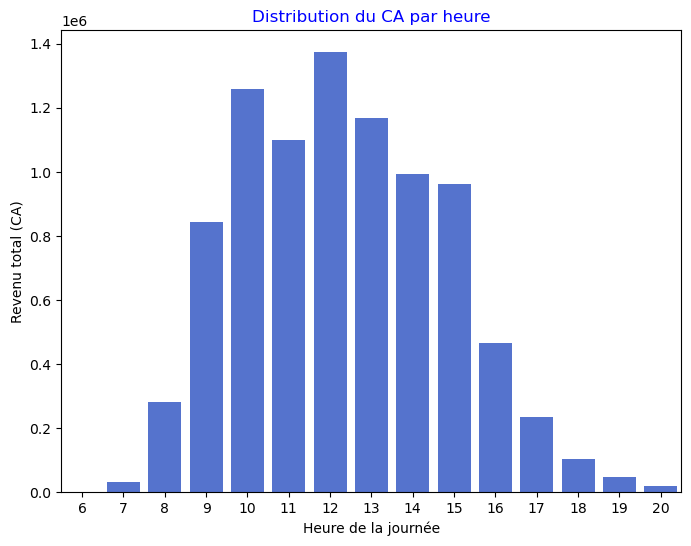

In [52]:
# barplot
plt.figure(figsize=(8,6))
sns.barplot(x=hourly_revenu.index, y=hourly_revenu.values, color='royalblue')
plt.title('Distribution du CA par heure', color='Blue')
plt.xlabel('Heure de la journée')
plt.ylabel('Revenu total (CA)')
plt.show()

In [53]:
# nbre de transactions par heure 
hourly_transactions = df.groupby('hour')['InvoiceNo'].nunique()
hourly_transactions

hour
6        1
7       29
8      555
9     1393
10    2226
11    2277
12    3130
13    2636
14    2274
15    2037
16    1100
17     544
18     169
19     144
20      18
Name: InvoiceNo, dtype: int64

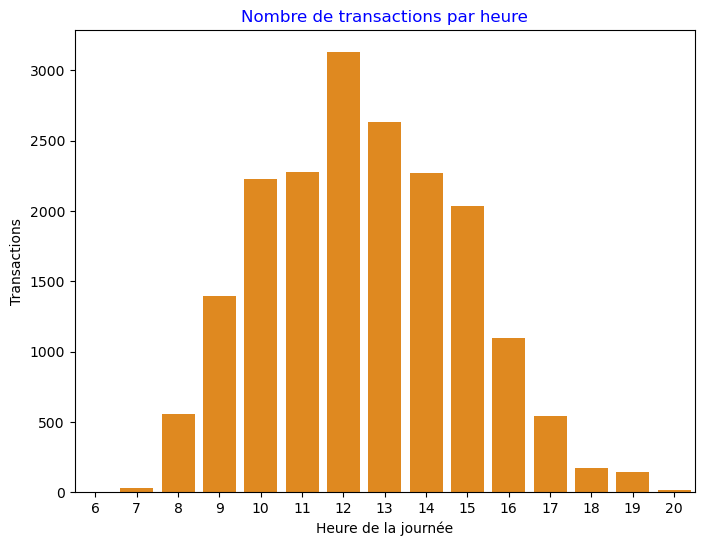

In [54]:
# barplot
plt.figure(figsize=(8,6))
sns.barplot(x=hourly_transactions.index, y=hourly_transactions.values, color='darkorange')
plt.title('Nombre de transactions par heure', color='Blue')
plt.xlabel('Heure de la journée')
plt.ylabel('Transactions')
plt.show()

In [55]:
# détection par écart-type
daily_revenu_serie = df.groupby(df['InvoiceDate'].dt.date)['TotalPrice'].sum()
daily_revenu_serie

InvoiceDate
2010-12-01     46192.49
2010-12-02     47197.57
2010-12-03     23876.63
2010-12-05     31361.28
2010-12-06     31009.33
                ...    
2011-12-05     58081.09
2011-12-06     45989.66
2011-12-07     69230.60
2011-12-08     50395.96
2011-12-09    184329.66
Name: TotalPrice, Length: 305, dtype: float64

In [56]:
# calcul des seuils
mean = daily_revenu_serie.mean()
mean

np.float64(29138.389816393446)

In [57]:
std = daily_revenu_serie.std()
std

17834.947343909113

In [58]:
threshold_high = mean + 3 * std
threshold_high

np.float64(82643.23184812079)

In [59]:
threshold_low = mean - 3 * std
threshold_low

np.float64(-24366.452215333895)

In [60]:
# anomalies
anomalies_std = daily_revenu_serie[(daily_revenu_serie > threshold_high) | (daily_revenu_serie < threshold_low)]
anomalies_std

InvoiceDate
2011-01-18     87559.21
2011-09-20    103377.68
2011-12-09    184329.66
Name: TotalPrice, dtype: float64

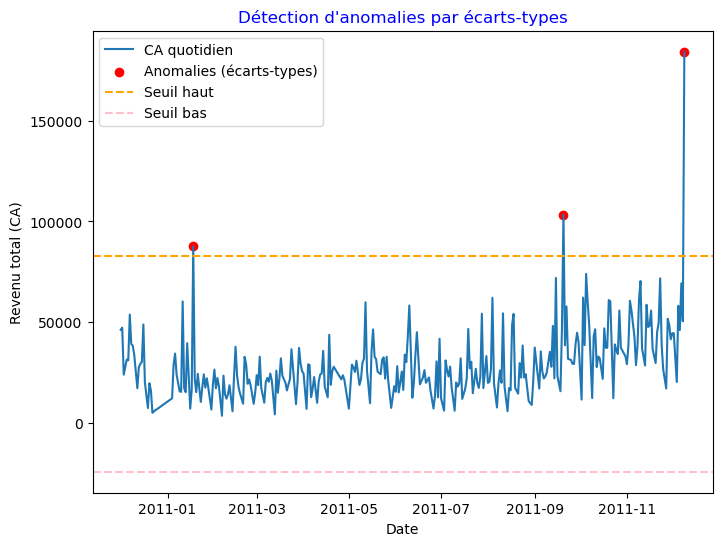

In [61]:
plt.figure(figsize=(8,6))
plt.plot(daily_revenu_serie.index, daily_revenu_serie.values, label='CA quotidien')
plt.scatter(anomalies_std.index, anomalies_std.values, color='red', label='Anomalies (écarts-types)')
plt.axhline(threshold_high, color='orange', linestyle='--', label='Seuil haut')
plt.axhline(threshold_low, color='pink', linestyle='--', label='Seuil bas')
plt.title('Détection d\'anomalies par écarts-types',color='Blue')
plt.xlabel('Date')
plt.ylabel('Revenu total (CA)')
plt.legend()
plt.show()

In [62]:
# détection par IQR (interquartile range)
Q1 = daily_revenu_serie.quantile(0.25)
Q1

np.float64(17999.181)

In [63]:
Q3 = daily_revenu_serie.quantile(0.75)
Q3

np.float64(36606.25)

In [64]:
IQR = Q3 - Q1
IQR

np.float64(18607.069)

In [65]:
lower_bound = Q1 - 1.5 * IQR
lower_bound

np.float64(-9911.422499999997)

In [66]:
upper_bound = Q3 + 1.5 * IQR
upper_bound

np.float64(64516.8535)

In [67]:
anomalies_iqr = daily_revenu_serie[(daily_revenu_serie < lower_bound) | (daily_revenu_serie > upper_bound)]
anomalies_iqr    

InvoiceDate
2011-01-18     87559.21
2011-09-15     71926.69
2011-09-20    103377.68
2011-10-05     73975.57
2011-11-10     70373.03
2011-11-23     71722.75
2011-12-07     69230.60
2011-12-09    184329.66
Name: TotalPrice, dtype: float64

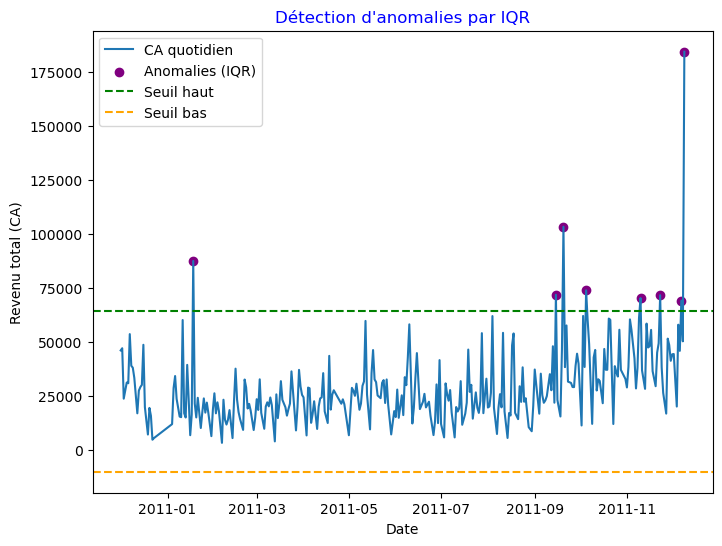

In [68]:
plt.figure(figsize=(8,6))
plt.plot(daily_revenu_serie.index, daily_revenu_serie.values, label='CA quotidien')
plt.scatter(anomalies_iqr.index, anomalies_iqr.values, label='Anomalies (IQR)', color='purple')
plt.axhline(upper_bound, color='green', linestyle='--', label='Seuil haut')
plt.axhline(lower_bound, color='orange', linestyle='--', label='Seuil bas')
plt.title('Détection d\'anomalies par IQR', color='Blue')
plt.xlabel('Date')
plt.ylabel('Revenu total (CA)')
plt.legend()
plt.show()

In [69]:
# détection par résidus STL
stl = STL(daily_revenu_serie, period=7)
result = stl.fit()
result

In [70]:
residuals = result.resid
residuals

InvoiceDate
2010-12-01    -1531.942787
2010-12-02     4359.909279
2010-12-03    -3421.440922
2010-12-05    -3570.160341
2010-12-06     4068.285017
                  ...     
2011-12-05     9801.927514
2011-12-06    -9371.269159
2011-12-07    -4671.544185
2011-12-08   -12655.463750
2011-12-09    28895.993952
Name: resid, Length: 305, dtype: float64

In [71]:
# seuil sur les résidus
res_mean = residuals.mean()
res_mean

np.float64(-99.37784570385344)

In [72]:
res_std = residuals.std()
res_std

10692.944842673278

In [73]:
res_threshold_high = res_mean + 2 * res_std
res_threshold_high

np.float64(21286.511839642702)

In [74]:
res_threshold_low = res_mean - 2 * res_std
res_threshold_low

np.float64(-21485.26753105041)

In [75]:
anomalies_resid = residuals[(residuals > res_threshold_high) | (residuals < res_threshold_low)]
anomalies_resid

InvoiceDate
2011-01-11    27802.281174
2011-01-18    46309.208353
2011-05-12    21865.852731
2011-07-28    23247.615496
2011-08-04    27276.544012
2011-08-11    27240.389301
2011-09-15    31266.384581
2011-09-20    40873.848060
2011-10-02   -22986.744595
2011-10-09   -24839.598495
2011-11-10    22705.499947
2011-12-01   -45126.502299
2011-12-09    28895.993952
Name: resid, dtype: float64

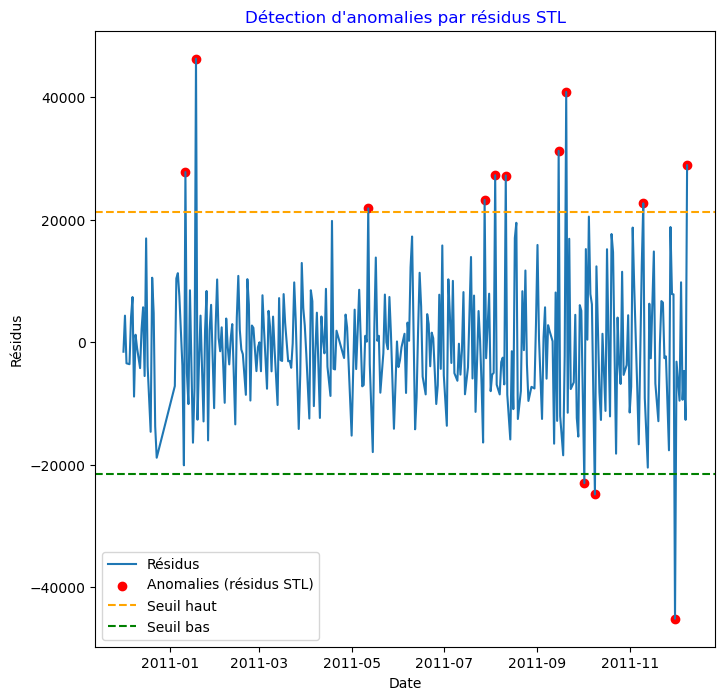

In [89]:
# visualisation
plt.figure(figsize=(8,8))
plt.plot(residuals.index, residuals.values, label='Résidus')
plt.scatter(anomalies_resid.index, anomalies_resid.values, color='red', label='Anomalies (résidus STL)')
plt.axhline(res_threshold_high, color='orange', linestyle='--', label='Seuil haut')
plt.axhline(res_threshold_low, color='green', linestyle='--', label='Seuil bas')
plt.title('Détection d\'anomalies par résidus STL', color='blue')
plt.xlabel('Date')
plt.ylabel('Résidus')
plt.legend()
plt.savefig("../outputs/figures/08_anomalies_residus.png", dpi=150, bbox_inches="tight")
plt.show()

In [77]:
# Quelle est la transaction avec la quantité la plus élevée ?
transaction_max_qty = df[df['Quantity'] == df['Quantity'].max()]
transaction_max_qty[['InvoiceNo', 'Description', 'Quantity', 'UnitPrice', 'CustomerID', 'Country', 'InvoiceDate']]

,InvoiceNo,Description,Quantity,UnitPrice,CustomerID,Country,InvoiceDate
392226,581483,"PAPER CRAFT , LITTLE BIRDIE",80995,2.08,16446,United Kingdom,2011-12-09 09:15:00


**Observation** : la quantité maximale (80 995) correspond à une transaction précise
ci-dessus. À vérifier : s'agit-il d'un vrai achat en gros (client grossiste, cohérent
avec le profil de la clientèle du dataset), ou d'une erreur de saisie (ex: un zéro de
trop) ? Le prix unitaire et le pays associés à cette ligne aident à trancher.

In [79]:
# Comparaison des 3 méthodes de détection d'anomalies
print(f"Anomalies détectées par écart-type : {len(anomalies_std)} jours")
print(f"Anomalies détectées par IQR : {len(anomalies_iqr)} jours")
print(f"Anomalies détectées par résidus STL : {len(anomalies_resid)} jours")

# Chevauchement entre les méthodes
jours_std = set(anomalies_std.index)
jours_iqr = set(anomalies_iqr.index)
jours_resid = set(anomalies_resid.index)

communs_std_iqr = jours_std & jours_iqr
communs_std_resid = jours_std & jours_resid
communs_iqr_resid = jours_iqr & jours_resid
communs_3_methodes = jours_std & jours_iqr & jours_resid

print(f"\nJours communs (écart-type ∩ IQR) : {len(communs_std_iqr)}")
print(f"Jours communs (écart-type ∩ résidus STL) : {len(communs_std_resid)}")
print(f"Jours communs (IQR ∩ résidus STL) : {len(communs_iqr_resid)}")
print(f"Jours détectés par les 3 méthodes à la fois : {len(communs_3_methodes)}")

Anomalies détectées par écart-type : 3 jours
Anomalies détectées par IQR : 8 jours
Anomalies détectées par résidus STL : 13 jours

Jours communs (écart-type ∩ IQR) : 3
Jours communs (écart-type ∩ résidus STL) : 3
Jours communs (IQR ∩ résidus STL) : 5
Jours détectés par les 3 méthodes à la fois : 3


**Interprétation** : plus le nombre de jours détectés par les 3 méthodes à la fois est
élevé, plus on peut être confiant que ce sont de vraies anomalies (signal fort, pas un
artefact d'une seule méthode). Une méthode qui détecte beaucoup plus de jours que les
deux autres est probablement trop sensible (trop de faux positifs) ou trop stricte
(passe à côté de vraies anomalies), selon le sens de l'écart.

---
# Conclusion de l'EDA

## Synthèse des observations clés

- **Échelle de l'activité** : 18 532 transactions, 4 338 clients, 3 665 produits, 37 pays,
  pour un chiffre d'affaires total de ~8,89M £ sur la période déc. 2010 - déc. 2011.
- **Concentration géographique** : le Royaume-Uni représente à lui seul ~85% du chiffre
  d'affaires - forte dépendance à un marché unique, les autres pays restent sous-exploités.
- **Produits phares** : quelques références dominent largement les ventes en volume et en CA
  (voir Top 10), suggérant une concentration à surveiller pour la gestion des stocks.
- **Saisonnalité** : la décomposition STL révèle une saisonnalité hebdomadaire claire, avec
  des pics d'activité à certaines heures/jours (voir heatmap).
- **Anomalies** : les 3 méthodes de détection (écart-type, IQR, résidus STL) s'accordent sur
  3 jours atypiques communs aux trois approches — un signal fort, sachant que la méthode
  écart-type est la plus stricte (3 jours détectés, tous confirmés par les 2 autres méthodes),
  tandis que les résidus STL sont plus sensibles (13 jours détectés, dont seulement 3 confirmés
  par les autres méthodes). Ces jours communs méritent une investigation métier en priorité.
- **Limite méthodologique** : rappel du notebook 01 - 33% des transactions brutes (celles sans
  CustomerID) ont été exclues de cette analyse, car centrée sur le comportement client. Le CA
  réel total de l'entreprise (achats invités inclus) est donc plus élevé que les 8,89M £ mesurés ici.

## Pour la suite du projet
Cette exploration prépare le terrain pour une future segmentation client (clustering) et
le dashboard Streamlit (03_KPI_analysis + dashboard interactif).